# Solar Generation Forecasting

This notebook develops a forecasting workflow for photovoltaic generation from a representative solar portfolio in Southern Italy.

The goal is to predict hourly solar generation using historical generation patterns and weather-related features. The resulting forecast will be used in the following notebooks to simulate Day-Ahead market positioning and evaluate the impact of forecast errors on trading performance.

In particular, this notebook covers:

- loading and cleaning photovoltaic generation data
- exploratory analysis of solar production patterns
- feature engineering for hourly forecasting
- baseline forecasting model
- machine learning forecasting model
- forecast evaluation
- preparation of generation forecasts for the trading workflow

## Configuration

In [104]:
from pathlib import Path

RAW_DATA_DIR = "../data/raw"
PROCESSED_DATA_DIR = "../data/processed"

SOLAR_FILE = "../data/raw/solar_generation_2023.csv"
OUTPUT_FILE = "../data/processed/solar_generation_forecast_2023.csv"

## Imports

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Load Solar Generation Data

The photovoltaic generation dataset is obtained from PVGIS hourly simulations for a representative solar portfolio located near Bari, Southern Italy.

Bari was selected because Southern Italy hosts a large share of the country's photovoltaic capacity and exhibits some of the highest solar irradiation levels in Europe. As a result, the region provides a realistic proxy for photovoltaic generation assets operating in the Italian power market.

The dataset includes hourly photovoltaic power output together with weather-related variables such as irradiance, temperature, and wind speed. These variables will be used to analyze generation patterns and develop forecasting models in the following sections.

In [106]:
solar_raw = pd.read_csv(
    SOLAR_FILE,
    skiprows=10
)

solar_raw.head()

,time,P,G(i),H_sun,T2m,WS10m,Int
0,20230101:0010,0.0,0.0,0.0,9.32,2.14,0.0
1,20230101:0110,0.0,0.0,0.0,9.16,2.00,0.0
2,20230101:0210,0.0,0.0,0.0,8.91,2.00,0.0
3,20230101:0310,0.0,0.0,0.0,8.70,2.14,0.0
4,20230101:0410,0.0,0.0,0.0,8.46,2.14,0.0


## Data Preparation

The raw PVGIS dataset contains hourly photovoltaic production together with weather-related variables.

Before performing the analysis, the dataset is cleaned and transformed into a structured time series suitable for forecasting applications.

In [107]:
# keep relevant columns
solar_df = solar_raw[
    [
        "time",
        "P",
        "G(i)",
        "H_sun",
        "T2m",
        "WS10m"
    ]
].copy()

# rename columns
solar_df.columns = [
    "datetime",
    "power",
    "irradiance",
    "sun_height",
    "temperature",
    "wind_speed"
]

solar_df.head()

,datetime,power,irradiance,sun_height,temperature,wind_speed
0,20230101:0010,0.0,0.0,0.0,9.32,2.14
1,20230101:0110,0.0,0.0,0.0,9.16,2.00
2,20230101:0210,0.0,0.0,0.0,8.91,2.00
3,20230101:0310,0.0,0.0,0.0,8.70,2.14
4,20230101:0410,0.0,0.0,0.0,8.46,2.14


## Create Datetime Index

The PVGIS timestamp format is converted into a standard Python datetime format to create a continuous hourly time series.

In [108]:
# remove PVGIS metadata rows at the end of the file
solar_df = solar_df[
    solar_df["datetime"].str.match(r"^\d{8}:\d{4}$")
].copy()

solar_df.tail()

,datetime,power,irradiance,sun_height,temperature,wind_speed
8755,20231231:1910,0.0,0.0,0.0,12.35,4.28
8756,20231231:2010,0.0,0.0,0.0,12.26,4.28
8757,20231231:2110,0.0,0.0,0.0,12.29,4.28
8758,20231231:2210,0.0,0.0,0.0,12.13,4.21
8759,20231231:2310,0.0,0.0,0.0,12.01,4.07


In [109]:
solar_df["datetime"] = pd.to_datetime(
    solar_df["datetime"],
    format="%Y%m%d:%H%M"
)

solar_df.head()

,datetime,power,irradiance,sun_height,temperature,wind_speed
0,2023-01-01 00:10:00,0.0,0.0,0.0,9.32,2.14
1,2023-01-01 01:10:00,0.0,0.0,0.0,9.16,2.00
2,2023-01-01 02:10:00,0.0,0.0,0.0,8.91,2.00
3,2023-01-01 03:10:00,0.0,0.0,0.0,8.70,2.14
4,2023-01-01 04:10:00,0.0,0.0,0.0,8.46,2.14


## Data Quality Checks

Basic quality checks are performed to verify data completeness and detect potential missing values before developing forecasting models.

In [110]:
print("Rows:", len(solar_df))
print("\nMissing values:")
print(solar_df.isna().sum())

# convert numeric columns
numeric_columns = [
    "power",
    "irradiance",
    "sun_height",
    "temperature",
    "wind_speed"
]

for col in numeric_columns:
    solar_df[col] = pd.to_numeric(solar_df[col])

solar_df.info()

Rows: 8760

Missing values:
datetime       0
power          0
irradiance     0
sun_height     0
temperature    0
wind_speed     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     8760 non-null   datetime64[ns]
 1   power        8760 non-null   float64       
 2   irradiance   8760 non-null   float64       
 3   sun_height   8760 non-null   float64       
 4   temperature  8760 non-null   float64       
 5   wind_speed   8760 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 479.1 KB


In [111]:
solar_df.describe()

,datetime,power,irradiance,sun_height,temperature,wind_speed
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2023-07-02 11:40:00,17581.927626,216.480628,15.239300,17.932062,3.901502
min,2023-01-01 00:10:00,0.000000,0.000000,0.000000,3.010000,0.000000
25%,2023-04-02 05:55:00,0.000000,0.000000,0.000000,12.170000,2.340000
50%,2023-07-02 11:40:00,0.000000,0.000000,0.000000,17.470000,3.590000
75%,2023-10-01 17:25:00,31294.000000,376.755000,27.940000,23.220000,5.100000
max,2023-12-31 23:10:00,93402.000000,1076.790000,72.000000,39.720000,13.030000
std,NaN,26128.373606,317.924852,20.219339,6.677977,2.135185


In [112]:
# convert power from W to kW
solar_df["power_kw"] = solar_df["power"] / 1000

solar_df = solar_df[
    [
        "datetime",
        "power",
        "power_kw",
        "irradiance",
        "sun_height",
        "temperature",
        "wind_speed"
    ]
]

## Solar Generation Time Series

The hourly photovoltaic generation profile is visualized over the entire year to identify seasonal patterns, production variability, and periods of high or low output.

Understanding these dynamics is essential before developing forecasting models and trading strategies.

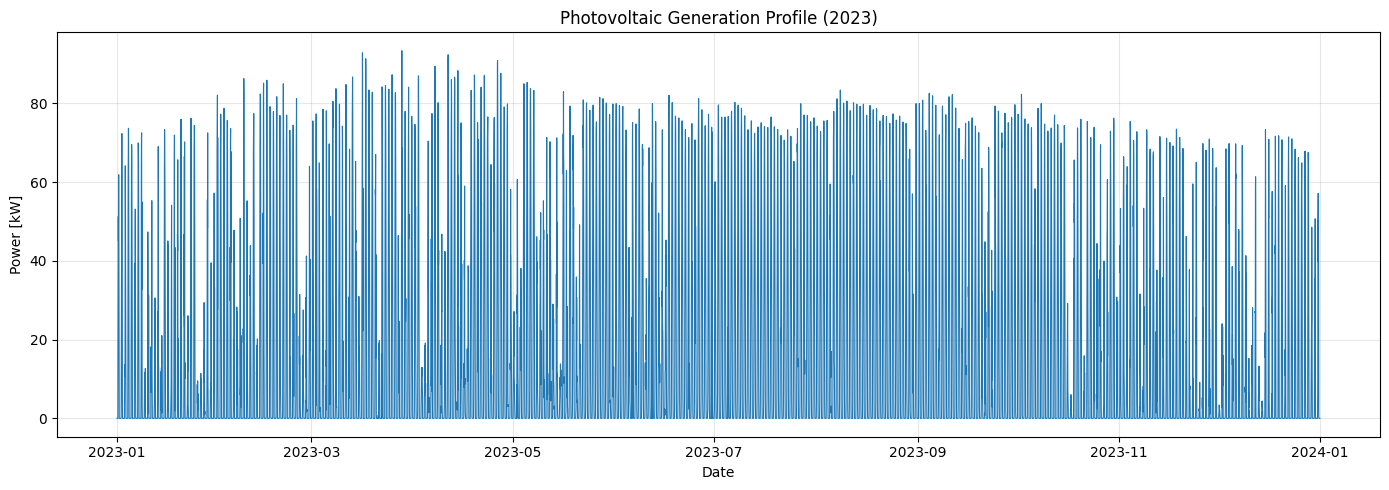

In [113]:
plt.figure(figsize=(14, 5))
plt.plot(
    solar_df["datetime"],
    solar_df["power_kw"],
    linewidth=0.8
)
plt.title("Photovoltaic Generation Profile (2023)")
plt.xlabel("Date")
plt.ylabel("Power [kW]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Average Hourly Generation Profile

Photovoltaic production follows a strong daily cycle driven by solar irradiation.

Analyzing the average production for each hour of the day helps identify the typical generation profile of the portfolio.

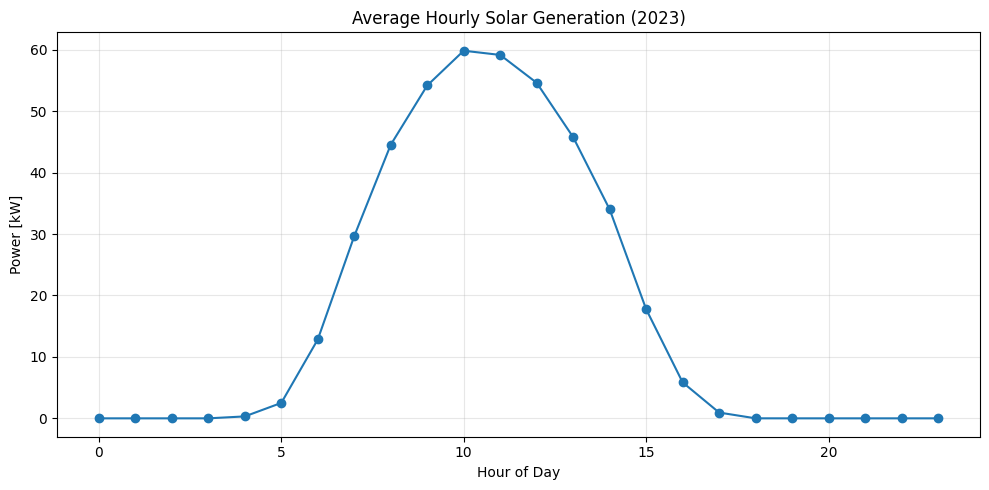

In [114]:
# extract hour
solar_df["hour"] = solar_df["datetime"].dt.hour

hourly_generation = (
    solar_df
    .groupby("hour")["power_kw"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_generation.index,
    hourly_generation.values,
    marker="o"
)
plt.title("Average Hourly Solar Generation (2023)")
plt.xlabel("Hour of Day")
plt.ylabel("Power [kW]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Average Monthly Generation Profile

Solar generation also exhibits strong seasonal variation due to changes in daylight duration and solar elevation throughout the year.

Monthly averages provide a useful overview of seasonal production dynamics.

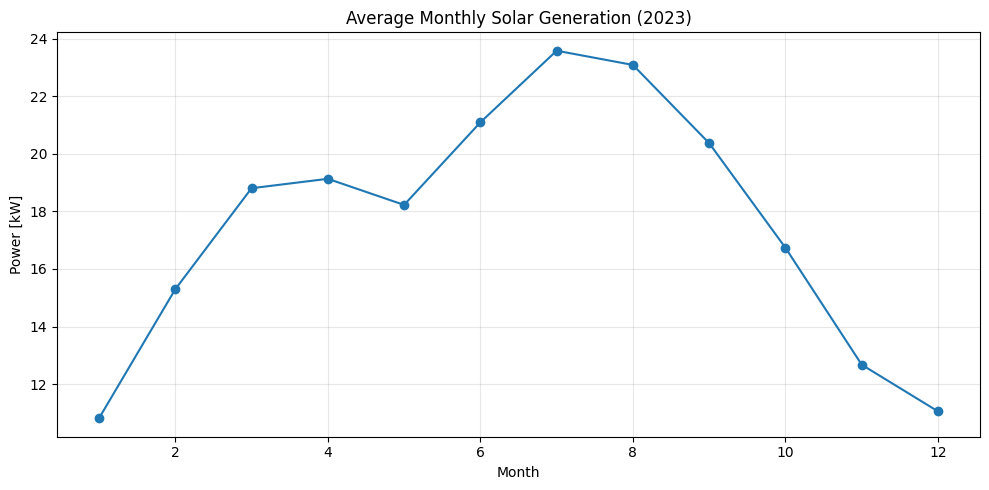

In [115]:
# extract month
solar_df["month"] = solar_df["datetime"].dt.month

monthly_generation = (
    solar_df
    .groupby("month")["power_kw"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_generation.index,
    monthly_generation.values,
    marker="o"
)
plt.title("Average Monthly Solar Generation (2023)")
plt.xlabel("Month")
plt.ylabel("Power [kW]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Key Observations

Several important generation patterns emerge from the analysis.

The annual generation profile shows the strong intermittency typical of photovoltaic assets, with production concentrated during daylight hours and substantial variability driven by weather conditions.

A pronounced intraday cycle is observed, with generation starting shortly after sunrise, peaking around midday, and declining toward sunset. Average production reaches its highest levels between 10:00 and 12:00, when solar irradiation is strongest.

Seasonal effects are also clearly visible. Average generation increases steadily from winter to summer, reaching its maximum during July and August when both solar elevation and daylight duration are highest. Production then gradually declines during autumn and winter months.

These recurring patterns suggest that solar generation can be forecast with reasonable accuracy using time-based and weather-related features. The next step is therefore to construct forecasting features and develop predictive models for hourly photovoltaic generation.

## Feature Engineering

To forecast photovoltaic generation, a set of explanatory variables is created from timestamp information and weather-related data.

In real-world renewable energy trading, future photovoltaic generation is forecast using weather predictions rather than observed weather conditions. To better approximate this operational setting, a synthetic irradiance forecast is created by introducing controlled uncertainty into the observed irradiance series.

This approach preserves the physical relationship between solar radiation and photovoltaic output while making the forecasting problem more realistic.

In [116]:
forecast_df = solar_df.copy()
forecast_df["hour"] = forecast_df["datetime"].dt.hour
forecast_df["month"] = forecast_df["datetime"].dt.month
forecast_df["day_of_year"] = forecast_df["datetime"].dt.dayofyear

# simulate an imperfect irradiance forecast
np.random.seed(42)

forecast_df["irradiance_forecast"] = (
    forecast_df["irradiance"]
    * np.random.normal(
        loc=1.0,
        scale=0.10,
        size=len(forecast_df)
    )
)

forecast_df["irradiance_forecast"] = (
    forecast_df["irradiance_forecast"]
    .clip(lower=0)
)

forecast_df = forecast_df[
    [
        "datetime",

        "power",
        "power_kw",

        "irradiance",
        "irradiance_forecast",

        "sun_height",
        "temperature",
        "wind_speed",

        "hour",
        "month",
        "day_of_year"
    ]
]

forecast_df.head()

,datetime,power,power_kw,irradiance,irradiance_forecast,sun_height,temperature,wind_speed,hour,month,day_of_year
0,2023-01-01 00:10:00,0.0,0.0,0.0,0.0,0.0,9.32,2.14,0,1,1
1,2023-01-01 01:10:00,0.0,0.0,0.0,0.0,0.0,9.16,2.00,1,1,1
2,2023-01-01 02:10:00,0.0,0.0,0.0,0.0,0.0,8.91,2.00,2,1,1
3,2023-01-01 03:10:00,0.0,0.0,0.0,0.0,0.0,8.70,2.14,3,1,1
4,2023-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,8.46,2.14,4,1,1


## Forecasting Dataset

The forecasting dataset combines time-based features with weather-related variables that influence photovoltaic generation.

The target variable is hourly photovoltaic power output expressed in kW.

In [117]:
feature_columns = [
    "hour",
    "month",
    "day_of_year",
    "irradiance_forecast",
    "sun_height",
    "temperature",
    "wind_speed"
]
target_column = "power_kw"

X = forecast_df[feature_columns]
y = forecast_df[target_column]

X.head()

,hour,month,day_of_year,irradiance_forecast,sun_height,temperature,wind_speed
0,0,1,1,0.0,0.0,9.32,2.14
1,1,1,1,0.0,0.0,9.16,2.00
2,2,1,1,0.0,0.0,8.91,2.00
3,3,1,1,0.0,0.0,8.70,2.14
4,4,1,1,0.0,0.0,8.46,2.14


## Train-Test Split

The dataset is split chronologically to avoid data leakage.

The first part of the year is used for model training, while the final months are reserved for out-of-sample forecast evaluation.

In [118]:
split_date = "2023-10-01"

train_mask = forecast_df["datetime"] < split_date
test_mask = forecast_df["datetime"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 6552
Test samples: 2208


## Baseline Forecast Model

A Linear Regression model is used as a simple baseline forecasting approach.

This baseline provides a reference point against which the Random Forest model can be evaluated. Comparing a simple linear model with a non-linear machine learning model helps assess whether additional model complexity improves forecasting performance.

In [119]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

## Random Forest Forecast Model

A Random Forest regressor is trained to predict hourly photovoltaic generation using both temporal and weather-related features.

Compared with the linear baseline, Random Forest can capture non-linear relationships between forecast irradiance, weather conditions, and photovoltaic output, without requiring extensive parameter tuning.

In [120]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

## Forecast Accuracy Evaluation

Forecasting performance is evaluated on the out-of-sample test period using standard regression metrics.

The Linear Regression model provides a simple benchmark, while the Random Forest model represents a more flexible non-linear forecasting approach.

In [121]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return mae, rmse, r2

linear_mae, linear_rmse, linear_r2 = evaluate_forecast(
    y_test,
    linear_predictions
)

rf_mae, rf_rmse, rf_r2 = evaluate_forecast(
    y_test,
    rf_predictions
)

metrics_df = pd.DataFrame({
    "model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE [kW]": [
        linear_mae,
        rf_mae
    ],
    "RMSE [kW]": [
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2
    ]
})

metrics_df

,model,MAE [kW],RMSE [kW],R²
0,Linear Regression,1.779148,2.899685,0.984057
1,Random Forest,1.065256,2.496753,0.988180


### Model Comparison

Both models achieve strong out-of-sample forecasting performance.

The Linear Regression baseline already performs well, indicating that photovoltaic generation has a strong relationship with forecast irradiance and other weather-related variables.

However, the Random Forest model improves forecast accuracy by reducing both MAE and RMSE, suggesting that non-linear relationships between irradiance, weather conditions, and photovoltaic output provide additional predictive value.

For this reason, the Random Forest forecast is selected for the trading workflow developed in the following notebook.

## Selected Model Performance

The Random Forest model achieves strong forecasting accuracy on the out-of-sample test period.

Although the model uses a simulated irradiance forecast rather than observed irradiance values, it is still able to capture the main drivers of photovoltaic generation and reproduce both seasonal and intraday production patterns.

This result demonstrates how weather forecasts can be effectively translated into renewable generation forecasts for short-term trading applications.

## Actual vs Forecast Generation

The Random Forest model is used to generate the final photovoltaic production forecast for the test period.

The comparison between actual and forecast generation provides a visual assessment of how well the model captures intraday and seasonal production dynamics.

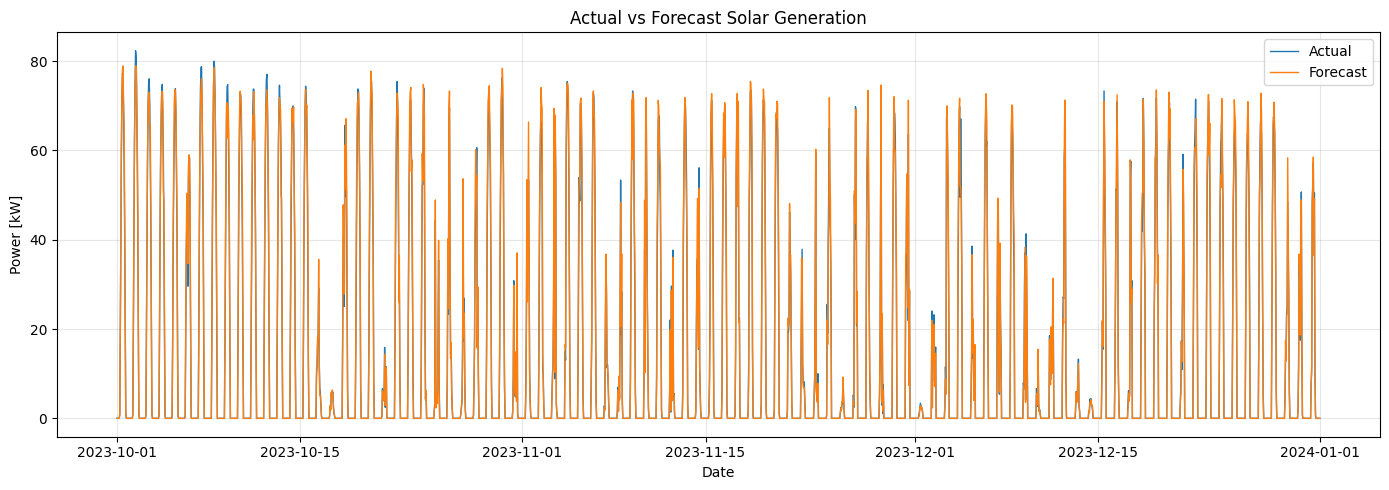

In [122]:
results_df = pd.DataFrame({
    "datetime": forecast_df.loc[test_mask, "datetime"],
    "actual": y_test,
    "forecast": rf_predictions
})

plt.figure(figsize=(14, 5))
plt.plot(
    results_df["datetime"],
    results_df["actual"],
    label="Actual",
    linewidth=1
)
plt.plot(
    results_df["datetime"],
    results_df["forecast"],
    label="Forecast",
    linewidth=1
)
plt.title("Actual vs Forecast Solar Generation")
plt.xlabel("Date")
plt.ylabel("Power [kW]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The forecast closely follows the actual photovoltaic generation profile across the test period.

Most forecast deviations occur during daylight hours, when production is sensitive to irradiance forecast uncertainty. This behavior is expected in renewable generation forecasting and represents the type of forecast error that can affect Day-Ahead market positions.

These forecast errors will be used conceptually in the following notebook to evaluate short-term trading decisions.

## Feature Importance

Feature importance analysis helps identify which variables contribute most to photovoltaic generation forecasts.

Understanding the relative importance of weather and temporal variables provides additional insight into the drivers of solar production.

In [123]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
3,irradiance_forecast,0.987870
0,hour,0.005352
5,temperature,0.002124
4,sun_height,0.001564
6,wind_speed,0.001537
2,day_of_year,0.001367
1,month,0.000186


### Interpretation

The feature importance analysis confirms that forecast solar irradiance is the dominant driver of photovoltaic generation forecasts, accounting for nearly all of the model's predictive power.

This result is consistent with the physical relationship between solar radiation and electricity production. Once forecast irradiance information is available, the additional contribution of weather and temporal variables becomes relatively small.

The importance assigned to the hour variable indicates that intraday solar patterns still provide useful information beyond irradiance alone, while temperature, wind speed, and seasonal indicators contribute only marginally to forecast accuracy.

From a trading perspective, these findings highlight the critical role of weather forecasting. Errors in irradiance forecasts can propagate directly into generation forecast errors, affecting market positions and ultimately trading performance.

---

## Key Findings

The analysis provides several important insights into photovoltaic generation forecasting and its application to renewable energy trading.

1. Photovoltaic generation exhibits strong intraday and seasonal patterns driven by solar irradiation, solar elevation, and daylight duration.

2. Average generation peaks during summer months and around midday hours, reflecting the underlying solar resource availability in Southern Italy.

3. To better reflect real-world renewable trading environments, a synthetic irradiance forecast was introduced to simulate weather forecast uncertainty.

4. Both Linear Regression and Random Forest models achieved strong out-of-sample forecasting performance, demonstrating that photovoltaic generation can be forecast with a high degree of accuracy using weather and temporal variables.

5. The Random Forest model outperformed the linear baseline, achieving a MAE of approximately 1.1 kW, an RMSE of 2.5 kW, and an R² of 0.99 on the test period.

6. Feature importance analysis confirms that forecast solar irradiance is the primary driver of photovoltaic generation forecasts, while temporal variables provide additional predictive information.

7. The results highlight the critical role of weather forecasting, as irradiance forecast errors can propagate directly into generation forecast errors and ultimately affect trading performance.

The generation forecasts developed in this notebook provide the foundation for the Day-Ahead trading strategy implemented in the next stage of the project.

## Save Forecast Dataset

The final forecast dataset is exported for use in the Day-Ahead trading strategy notebook.

In [124]:
results_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Forecast dataset saved to {OUTPUT_FILE}")

Forecast dataset saved to ../data/processed/solar_generation_forecast_2023.csv
